In [2]:
import os

# change directory one up 
os.chdir('..')


In [21]:
import importlib
import utils
importlib.reload(utils)
from notebooks.utils import *

In [39]:

prefix_performance_clicks = 'test_clicks_param_shift_'
prefix_performance_relevance = 'test_relevance_param_shift_'

folder_path = "results/Baidu_ULTR_position/baidu_subset=train_Baidu_ULTRA_part1.npz,data=Custom_dataset_deep,experiment=Baidu_ULTR_position,logging_policy_ranker=ordered,logging_policy_sampler=e_greedy,policy_temperature=0.0,relevance=deep,relevance_tower=deeper"

# Load performance (clicks)
perf_df = load_and_concat_multi_shift_files(
    folder_path,
    prefix_performance_clicks,
    'relevance_shift',
    'param_idx'
)

# Load relevance
rel_df = load_and_concat_multi_shift_files(
    folder_path,
    prefix_performance_relevance,
    'relevance_shift',
    'param_idx'
)

data = np.load("../ltr_datasets/train_Baidu_ULTRA_part1.npz", allow_pickle=True)
padded_positions = data['padded_positions']
counts = np.sum(padded_positions != -1, axis=0)
perf_df["sample_count"] = perf_df["param_idx"].map(
    {i: count for i, count in enumerate(counts)}
)



['test_clicks_param_shift_0.0_idx21.csv', 'test_clicks_param_shift_0.0_idx2.csv', 'test_clicks_param_shift_-1.5_idx11.csv', 'test_clicks_param_shift_-3.0_idx17.csv', 'test_clicks_param_shift_-3.0_idx16.csv', 'test_clicks_param_shift_-1.5_idx10.csv', 'test_clicks_param_shift_0.0_idx3.csv', 'test_clicks_param_shift_0.0_idx20.csv', 'test_clicks_param_shift_0.0_idx1.csv', 'test_clicks_param_shift_-1.5_idx12.csv', 'test_clicks_param_shift_-3.0_idx14.csv', 'test_clicks_param_shift_-3.0_idx15.csv', 'test_clicks_param_shift_-1.5_idx13.csv', 'test_clicks_param_shift_0.0_idx0.csv', 'test_clicks_param_shift_0.0_idx4.csv', 'test_clicks_param_shift_-1.5_idx17.csv', 'test_clicks_param_shift_-3.0_idx11.csv', 'test_clicks_param_shift_-3.0_idx10.csv', 'test_clicks_param_shift_-1.5_idx16.csv', 'test_clicks_param_shift_0.0_idx5.csv', 'test_clicks_param_shift_0.0_idx7.csv', 'test_clicks_param_shift_0.0_idx18.csv', 'test_clicks_param_shift_3.0_idx9.csv', 'test_clicks_param_shift_-1.5_idx14.csv', 'test_clic

In [40]:

from scipy.stats import chi2

# Compute global delta loss first
baseline_loss = perf_df.loc[perf_df["relevance_shift"] == 0, "loss"].mean()
perf_df["delta_loss"] = perf_df["loss"] - baseline_loss
perf_df["delta_loss_times_samples"] = perf_df["delta_loss"] * perf_df["sample_count"]
perf_df.dropna(inplace=True)
def compute_identifiability(df, thresholds=[0.05, 0.001, 0.0001]):
    required = {
        'relevance_shift', 'param_idx', 'loss',
        'sample_count', 'delta_loss', 'delta_loss_times_samples'
    }
    if not required.issubset(df.columns):
        raise ValueError(f"Missing columns: {required - set(df.columns)}")

    model_threshold = 0.05/df.param_idx.nunique()
    full_identifiability = True

    chi2_critical = {thr: chi2.ppf(1 - thr, df=1) for thr in thresholds}

    # Precompute minimal p-value per row
    df = df.copy()
    df["min_pval"] = np.inf
    for thr, crit in chi2_critical.items():
        mask = df["delta_loss_times_samples"] >= crit
        df.loc[mask, "min_pval"] = np.minimum(df.loc[mask, "min_pval"], thr)

    def first_identifiable(sub, sign):
        s = sub[sub["relevance_shift"] * sign > 0]
        if s.empty:
            return None, None
        s = s.sort_values("relevance_shift", ascending=(sign > 0))
        s = s[s["min_pval"] < np.inf]
        if s.empty:
            return None, None
        row = s.iloc[0]
        return row["min_pval"], row["relevance_shift"]

    results = {}


    print(f"{'Param':>5} | {'Neg p':>7} | {'Neg Δ':>7} | {'Pos Δ':>7} | "
          f"{'Avg ΔLoss':>10} | {'Samples':>8} | {'Conclusion':>22}")
    print("-" * 95)

    for param, sub in df.groupby("param_idx"):
        neg_thr, neg_shift = first_identifiable(sub, sign=-1)
        pos_thr, pos_shift = first_identifiable(sub, sign=+1)
        if (neg_thr is None) or (pos_thr is None):
            full_identifiability = False
        elif min(neg_thr, pos_thr) > model_threshold or (neg_thr is None) or (pos_thr is None):
            full_identifiability = False

        avg_delta = (
            sub["delta_loss_times_samples"].sum() /
            sub["sample_count"].sum()
        )
        total_samples = sub["sample_count"].sum()

        if neg_thr is None and pos_thr is None:
            conclusion = "unidentified"
        elif neg_thr is not None and pos_thr is not None:
            conclusion = "identified"
        else:
            conclusion = "practically unidentified"

        max_delta = sub["delta_loss"].max()

        results[param] = (
            (neg_thr, pos_thr),
            (neg_shift, pos_shift),
            max_delta,
            total_samples,
            conclusion
        )

        print(f"{param:>5} | {str(neg_thr):>7} | {str(neg_shift):>7} | "
              f"{str(pos_shift):>7} | {max_delta:>10.6f} | "
              f"{total_samples:>9} | {conclusion:>22}")


    if full_identifiability:
        print(f"Final Model conclusion: The model is identified with a bonferroni-corrected p-value of 0.05.")
    else:
        print(f"Final Model conclusion: The model is not found to be identified.")

    return results

# Usage
identifiability_results = compute_identifiability(perf_df, thresholds=[0.05, 0.001, 0.0001])




Param |   Neg p |   Neg Δ |   Pos Δ |  Avg ΔLoss |  Samples |             Conclusion
-----------------------------------------------------------------------------------------------
    0 |  0.0001 |    -1.5 |     3.0 |   0.001853 | 2501090.0 |             identified
    1 |  0.0001 |    -1.5 |     3.0 |   0.001022 | 2430155.0 |             identified
    2 |  0.0001 |    -1.5 |     3.0 |   0.000301 | 2575640.0 |             identified
    3 |  0.0001 |    -3.0 |     3.0 |   0.000391 | 2570180.0 |             identified
    4 |  0.0001 |    -3.0 |     3.0 |   0.003672 | 2595790.0 |             identified
    5 |  0.0001 |    -1.5 |    None |   0.002680 | 2624070.0 | practically unidentified
    6 |  0.0001 |    -3.0 |     1.5 |   0.000660 | 2745480.0 |             identified
    7 |  0.0001 |    -1.5 |     1.5 |   0.001908 | 2606895.0 |             identified
    8 |  0.0001 |    -1.5 |    None |   0.000839 | 2782795.0 | practically unidentified
    9 |  0.0001 |    -1.5 |    None |   0

/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_61396/4152429532.py:273: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


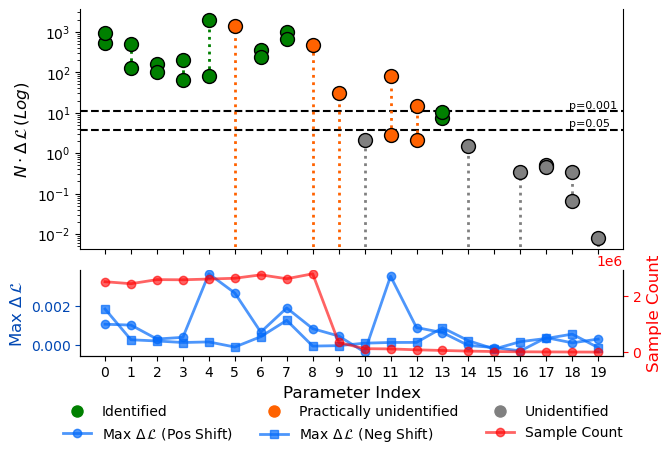

In [41]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import cm
import numpy as np


def plot_identifiability_summary(
    identifiability_results,
    perf_df,
    *,
    output_path=None,
    x_tick_rotation=0,
    figsize=(7, 4.5),
    comparison_lines=((3.84, "p=0.05"), (10.83, "p=0.001")),
    color_map=None,
    avg_loss_color="#046BFAB5",
    sample_count_color="#FF00009C",
    avg_loss_text_color="#0047B3",
    sample_count_text_color="#FF0000",
):
    """
    Plot identifiability summary with:
      1) Signed (Δ Loss × Sample Count) on log scale (top panel)
      2) Max Δ Loss (neg/pos) and Sample Count context (bottom panel)

    Parameters
    ----------
    identifiability_results : dict
        Mapping param_idx -> tuple where:
            [2] = avg delta loss
            [3] = sample count
            [4] = identifiability conclusion (string)

    perf_df : pandas.DataFrame
        Must contain columns:
            - param_idx
            - relevance_shift (signed)
            - delta_loss
            - sample_count

    output_path : str or None, optional
        If provided, saves figure to this path.

    figsize : tuple, optional
        Figure size.

    comparison_lines : iterable of (float, str), optional
        Horizontal reference lines for Δ loss × sample count.

    color_map : dict or None, optional
        Mapping conclusion -> color.
        Defaults to:
            {
                "identified": "green",
                "practically unidentified": "#FF6200",
                "unidentified": "gray"
            }

    Returns
    -------
    fig : matplotlib.figure.Figure
    axes : tuple(matplotlib.axes.Axes, matplotlib.axes.Axes)
        (ax_top, ax_bottom)
    """

    if color_map is None:
        color_map = {
            "identified": "green",
            "practically unidentified": "#FF6200",
            "unidentified": "gray",
        }

    # -----------------------
    # Extract per-parameter data
    # -----------------------
    params = sorted(identifiability_results.keys())

    sample_counts = [identifiability_results[p][3] for p in params]
    conclusions = [identifiability_results[p][4].strip().lower() for p in params]
    dot_colors = [color_map[c] for c in conclusions]

    # -----------------------
    # Δ Loss × Sample Count (signed)
    # -----------------------
    neg_df = perf_df[perf_df["relevance_shift"] < 0]
    pos_df = perf_df[perf_df["relevance_shift"] > 0]

    delta_loss_times_samples_neg = (
        neg_df.assign(stat=lambda d: d.delta_loss * d.sample_count)
            .groupby("param_idx")["stat"]
            .max()
    )

    delta_loss_times_samples_pos = (
        pos_df.assign(stat=lambda d: d.delta_loss * d.sample_count)
            .groupby("param_idx")["stat"]
            .max()
    )
    delta_loss_times_samples_neg = [
        delta_loss_times_samples_neg.get(p, 0) for p in params
    ]
    delta_loss_times_samples_pos = [
        delta_loss_times_samples_pos.get(p, 0) for p in params
    ]

    # -----------------------
    # Max Δ Loss (context)
    # -----------------------
    max_delta_neg = neg_df.groupby("param_idx")["delta_loss"].max()
    max_delta_pos = pos_df.groupby("param_idx")["delta_loss"].max()

    max_delta_neg_vals = [max_delta_neg.get(p, 0) for p in params]
    max_delta_pos_vals = [max_delta_pos.get(p, 0) for p in params]

    # -----------------------
    # Figure layout
    # -----------------------
    fig, (ax_top, ax_bottom) = plt.subplots(
        2,
        1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={"height_ratios": [2.5, 0.9], "hspace": 0.13},
    )

    # =========================
    # TOP PANEL
    # =========================
    ax_top.set_yscale("log")

    for i, p in enumerate(params):
        y_neg = delta_loss_times_samples_neg[i]
        y_pos = delta_loss_times_samples_pos[i]
        color = dot_colors[i]

        ax_top.vlines(
            x=p,
            ymin=min(y_neg, y_pos),
            ymax=max(y_neg, y_pos),
            color=color,
            linewidth=2,
            linestyle=":",
        )

        ax_top.scatter(
            p,
            y_neg,
            color=color,
            edgecolor="black",
            s=100,
            linewidth=1,
            zorder=3,
        )
        ax_top.scatter(
            p,
            y_pos,
            color=color,
            edgecolor="black",
            s=100,
            linewidth=1,
            zorder=3,
        )

    ax_top.set_ylabel(f"$ N \\cdot \\Delta \\, \\mathcal{{L}}\\, (Log)$", fontsize=12)

    for yval, label in comparison_lines:
        ax_top.axhline(y=yval, color="black", ls="--", lw=1.5, zorder=1)
        ax_top.text(
            max(params) * 0.94,
            yval * 1.05,
            label,
            ha="left",
            va="bottom",
            fontsize=8,
        )

    ax_top.spines["top"].set_visible(False)
    ax_top.spines["right"].set_visible(True)

    # =========================
    # BOTTOM PANEL
    # =========================
    ax_bottom.plot(
        params,
        max_delta_neg_vals,
        color=avg_loss_color,
        marker="o",
        linewidth=2,
        label="Max Δ Loss (neg)",
    )
    ax_bottom.plot(
        params,
        max_delta_pos_vals,
        color=avg_loss_color,
        marker="s",
        linewidth=2,
        label="Max Δ Loss (pos)",
    )

    ax_bottom.set_ylabel(
        f"$ \\text{{Max }} \\Delta \\, \\mathcal{{L}} $",
        color=avg_loss_text_color,
        fontsize=12,
    )
    ax_bottom.tick_params(axis="y", colors=avg_loss_text_color)

    ax_bottom_r = ax_bottom.twinx()
    ax_bottom_r.plot(
        params,
        sample_counts,
        color=sample_count_color,
        marker="o",
        linewidth=2,
        label="Sample Count",
    )
    ax_bottom_r.set_ylabel(
        "Sample Count",
        color=sample_count_text_color,
        fontsize=12,
    )
    ax_bottom_r.tick_params(axis="y", colors=sample_count_text_color)

    ax_bottom.set_xlabel("Parameter Index", fontsize=12)
    ax_bottom.set_xticks(params)
    ax_bottom.set_xticklabels(params, rotation=x_tick_rotation)

    ax_bottom.spines["top"].set_visible(False)
    ax_bottom_r.spines["top"].set_visible(False)

    # =========================
    # LEGEND
    # =========================
    legend_ident = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor=color,
            markersize=10,
            label=label.capitalize(),
        )
        for label, color in color_map.items()
    ]

    legend_lines = [
        Line2D([0], [0], color=avg_loss_color, lw=2, marker="o", label=f"$ \\text{{Max }} \\Delta \\, \\mathcal{{L}} \\text{{ (Pos Shift)}} $"),
        Line2D([0], [0], color=avg_loss_color, lw=2, marker="s", label=f"$ \\text{{Max }} \\Delta \\, \\mathcal{{L}} \\text{{ (Neg Shift)}} $"),
        Line2D(
            [0],
            [0],
            color=sample_count_color,
            lw=2,
            marker="o",
            label="Sample Count",
        ),
    ]

    legend_elements = [
        legend_ident[0], legend_lines[0],
        legend_ident[1], legend_lines[1],
        legend_ident[2], legend_lines[2],
    ]

    fig.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.03),
        ncol=3,
        frameon=False,
    )

    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight", pad_inches=0.05)

    plt.show()

    return fig, (ax_top, ax_bottom)


_, _ =plot_identifiability_summary(
    identifiability_results,
    perf_df,
    output_path="notebooks/plots/position_bias_Identifiability_BaiduULTRA.pdf",
)

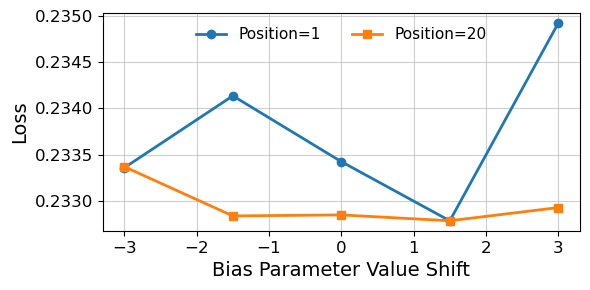

In [42]:
import matplotlib.pyplot as plt

params_to_plot = [0, 19]

fig, ax = plt.subplots(figsize=(6, 3))

for param_idx, linestyle, marker in zip(params_to_plot, ['-', '-'], ['o', 's']):
    ax.plot(
        perf_df[perf_df['param_idx'] == param_idx]['relevance_shift'],
        perf_df[perf_df['param_idx'] == param_idx]['loss'],
        linestyle=linestyle,
        marker=marker,
        linewidth=2,
        label=f'Position={param_idx+1}'
    )

ax.set_xlabel('Bias Parameter Value Shift', fontsize=14)
ax.set_ylabel('Loss', fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.grid(True, alpha=0.6)

ax.legend(fontsize=11, frameon=False, ncol=2, loc='upper center')
plt.tight_layout()
plt.savefig("notebooks/plots/Real_world_front_page_example.pdf", dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.show()

['test_clicks_param_shift_0.0_idx2.csv', 'test_clicks_param_shift_-1.5_idx11.csv', 'test_clicks_param_shift_-1.5_idx10.csv', 'test_clicks_param_shift_0.0_idx3.csv', 'test_clicks_param_shift_0.0_idx1.csv', 'test_clicks_param_shift_-1.5_idx12.csv', 'test_clicks_param_shift_0.0_idx0.csv', 'test_clicks_param_shift_0.0_idx4.csv', 'test_clicks_param_shift_-3.0_idx11.csv', 'test_clicks_param_shift_-3.0_idx10.csv', 'test_clicks_param_shift_0.0_idx5.csv', 'test_clicks_param_shift_0.0_idx7.csv', 'test_clicks_param_shift_3.0_idx9.csv', 'test_clicks_param_shift_-3.0_idx12.csv', 'test_clicks_param_shift_-1.5_idx9.csv', 'test_clicks_param_shift_-1.5_idx8.csv', 'test_clicks_param_shift_3.0_idx8.csv', 'test_clicks_param_shift_0.0_idx6.csv', 'test_clicks_param_shift_-3.0_idx7.csv', 'test_clicks_param_shift_1.5_idx7.csv', 'test_clicks_param_shift_1.5_idx6.csv', 'test_clicks_param_shift_-3.0_idx6.csv', 'test_clicks_param_shift_-3.0_idx4.csv', 'test_clicks_param_shift_1.5_idx4.csv', 'test_clicks_param_shi

/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_61396/4152429532.py:273: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


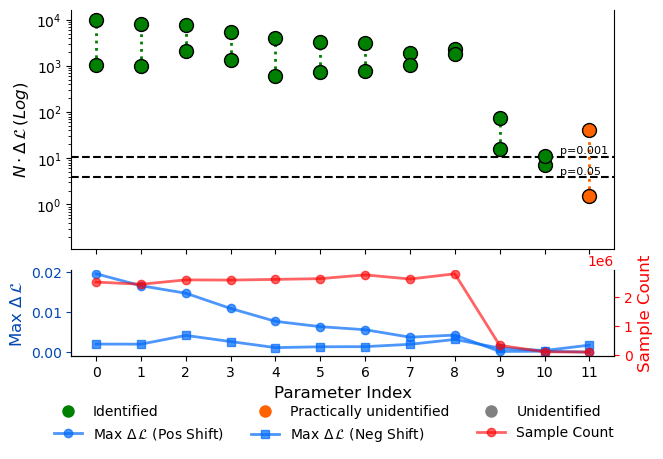

In [43]:

prefix_performance_clicks = 'test_clicks_param_shift_'
prefix_performance_relevance = 'test_relevance_param_shift_'

folder_path = "results/Baidu_ULTR_position/baidu_subset=train_Baidu_ULTRA_short.npz,data=Custom_dataset_deep,experiment=Baidu_ULTR_position,logging_policy_ranker=ordered,logging_policy_sampler=e_greedy,policy_temperature=0.0,relevance=deep,relevance_tower=deeper"

# Load performance (clicks)
perf_df = load_and_concat_multi_shift_files(
    folder_path,
    prefix_performance_clicks,
    'relevance_shift',
    'param_idx'
)

data = np.load("../ltr_datasets/train_Baidu_ULTRA_short.npz", allow_pickle=True)
padded_positions = data['padded_positions']
counts = np.sum(padded_positions != -1, axis=0)
perf_df["sample_count"] = perf_df["param_idx"].map(
    {i: count for i, count in enumerate(counts)}
)

baseline_loss = perf_df.loc[perf_df["relevance_shift"] == 0, "loss"].mean()
perf_df["delta_loss"] = perf_df["loss"] - baseline_loss
perf_df["delta_loss_times_samples"] = perf_df["delta_loss"] * perf_df["sample_count"]
perf_df.dropna(inplace=True)


identifiability_results = compute_identifiability(perf_df, thresholds=[0.05, 0.001, 0.0001])

_, _ =plot_identifiability_summary(
    identifiability_results,
    perf_df,
    output_path="notebooks/plots/position_bias_Identifiability_BaiduULTRA_short.pdf",
)


['test_clicks_param_shift_0.0_idx2.csv', 'test_clicks_param_shift_-1.5_idx11.csv', 'test_clicks_param_shift_-1.5_idx10.csv', 'test_clicks_param_shift_0.0_idx3.csv', 'test_clicks_param_shift_0.0_idx1.csv', 'test_clicks_param_shift_-1.5_idx12.csv', 'test_clicks_param_shift_0.0_idx0.csv', 'test_clicks_param_shift_0.0_idx4.csv', 'test_clicks_param_shift_-3.0_idx11.csv', 'test_clicks_param_shift_-3.0_idx10.csv', 'test_clicks_param_shift_0.0_idx5.csv', 'test_clicks_param_shift_0.0_idx7.csv', 'test_clicks_param_shift_3.0_idx9.csv', 'test_clicks_param_shift_-3.0_idx12.csv', 'test_clicks_param_shift_-1.5_idx9.csv', 'test_clicks_param_shift_-1.5_idx8.csv', 'test_clicks_param_shift_3.0_idx8.csv', 'test_clicks_param_shift_0.0_idx6.csv', 'test_clicks_param_shift_-3.0_idx7.csv', 'test_clicks_param_shift_1.5_idx7.csv', 'test_clicks_param_shift_1.5_idx6.csv', 'test_clicks_param_shift_-3.0_idx6.csv', 'test_clicks_param_shift_-3.0_idx4.csv', 'test_clicks_param_shift_1.5_idx4.csv', 'test_clicks_param_shi

/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_61396/4152429532.py:273: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


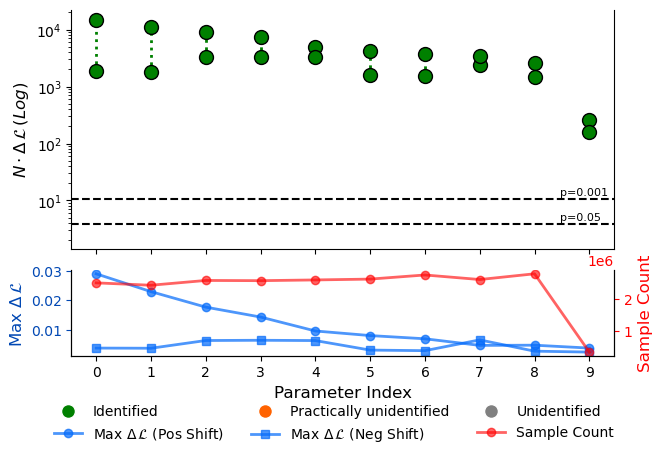

In [44]:

prefix_performance_clicks = 'test_clicks_param_shift_'
prefix_performance_relevance = 'test_relevance_param_shift_'

folder_path = "results/Baidu_ULTR_position/baidu_subset=train_Baidu_ULTRA_very_short.npz,data=Custom_dataset_deep,experiment=Baidu_ULTR_position,logging_policy_ranker=ordered,logging_policy_sampler=e_greedy,policy_temperature=0.0,relevance=deep,relevance_tower=deeper"

# Load performance (clicks)
perf_df = load_and_concat_multi_shift_files(
    folder_path,
    prefix_performance_clicks,
    'relevance_shift',
    'param_idx'
)

data = np.load("../ltr_datasets/train_Baidu_ULTRA_very_short.npz", allow_pickle=True)
padded_positions = data['padded_positions']
counts = np.sum(padded_positions != -1, axis=0)
perf_df["sample_count"] = perf_df["param_idx"].map(
    {i: count for i, count in enumerate(counts)}
)

baseline_loss = perf_df.loc[perf_df["relevance_shift"] == 0, "loss"].mean()
perf_df["delta_loss"] = perf_df["loss"] - baseline_loss
perf_df["delta_loss_times_samples"] = perf_df["delta_loss"] * perf_df["sample_count"]
perf_df.dropna(inplace=True)


identifiability_results = compute_identifiability(perf_df, thresholds=[0.05, 0.001, 0.0001])

_, _ =plot_identifiability_summary(
    identifiability_results,
    perf_df,
    output_path="notebooks/plots/position_bias_Identifiability_BaiduULTRA_short.pdf",
)


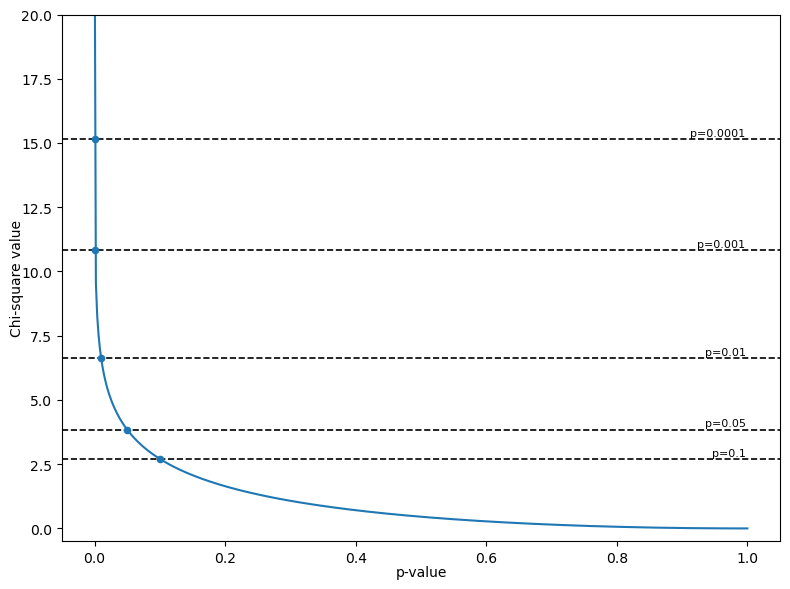

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# choose degrees of freedom
df = 1

# p-values from 0 to 1 (but avoid exactly 0)
p = np.linspace(0.000001, 0.9999, 500)
chi_vals = chi2.ppf(1 - p, df)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(p, chi_vals)

# special p-values
special_p = np.array([0.01, 0.05, 0.10, 0.001, 0.0001])
special_chi = chi2.ppf(1 - special_p, df)

# --- draw horizontal red dashed lines instead of dots ---
COMPARISON_LINES = list(zip(special_chi, [f"p={p}" for p in special_p]))

xmin, xmax = ax.get_xlim()

for yval, label in COMPARISON_LINES:
    ax.axhline(y=yval, color="black", ls="--", lw=1.2, alpha=1)
    ax.text(
        xmax * 0.95, yval + 0.05,
        label, color="black", fontsize=8, ha="right", va="bottom",
        backgroundcolor="white", alpha=1,
        zorder=-10
    )
special_p = np.array([0.01, 0.05, 0.10, 0.001, 0.0001])
special_chi = chi2.ppf(1 - special_p, df)

plt.scatter(special_p, special_chi, s=20, zorder=5)
ax.set_ylim(-0.5, 20)
# labels
ax.set_xlabel("p-value")
ax.xaxis.labelpad = 0
ax.set_ylabel("Chi-square value")
ax.yaxis.labelpad = -2
plt.tight_layout()
plt.savefig("notebooks/plots/chi_square_p_values.pdf", dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.show()


In [12]:
def load_and_concat_multi_shift_files(folder_path, prefix, column_name_relevance, column_name_idx, multi_bias=False):
    import os
    files = os.listdir(folder_path)
    shift_files = [f for f in files if f.startswith(prefix)]
    print("Found files:", shift_files)

    def parse_multi_bias_name(f):
        """Return (shift_value, idx_value, bias_type) from file name."""
        parts = f.replace('.csv', '').split('_')
        shift_value = float(parts[4])
        idx_value = int(parts[5].replace("idx", ""))

        # Extract bias_type
        bias_index = parts.index("bias")
        bias_type = "_".join(parts[bias_index + 1:])

        return shift_value, idx_value, bias_type

    if not multi_bias:
        # Sort by shift value, then by idx
        shift_files = sorted(shift_files, key=lambda x: float(x.split('_')[-2].replace('.csv', '')))
        shift_files = sorted(shift_files, key=lambda x: int(x.split('idx')[-1].replace('.csv', '')))

        for idx, f in enumerate(shift_files):
            df = pd.read_csv(os.path.join(folder_path, f))
            df[column_name_relevance] = float(f.split('_')[-2].replace('.csv',''))
            df[column_name_idx] = int(f.split('idx')[-1].replace('.csv',''))
            if idx == 0:
                combined_df = df
            else:
                combined_df = pd.concat([combined_df, df], ignore_index=True)

    else:
        # Sort by: shift_value → idx → bias_type
        shift_files = sorted(shift_files, key=lambda f: parse_multi_bias_name(f))

        for idx, f in enumerate(shift_files):
            df = pd.read_csv(os.path.join(folder_path, f))
            shift_value, idx_value, bias_type = parse_multi_bias_name(f)

            df[column_name_relevance] = shift_value
            df[column_name_idx] = idx_value
            df["bias_type"] = bias_type[4:]

            if idx == 0:
                combined_df = df
            else:
                combined_df = pd.concat([combined_df, df], ignore_index=True)

    return combined_df


Found files: ['test_clicks_param_shift_-1.5_idx16_bias_typemedia_type.csv', 'test_clicks_param_shift_-1.5_idx8_bias_typeserp_height.csv', 'test_clicks_param_shift_1.5_idx9_bias_typeposition.csv', 'test_clicks_param_shift_1.5_idx29_bias_typemedia_type.csv', 'test_clicks_param_shift_-3.0_idx8_bias_typeslipoff_count_after_click.csv', 'test_clicks_param_shift_1.5_idx17_bias_typemedia_type.csv', 'test_clicks_param_shift_3.0_idx1_bias_typeslipoff_count_after_click.csv', 'test_clicks_param_shift_-1.5_idx28_bias_typemedia_type.csv', 'test_clicks_param_shift_-1.5_idx4_bias_typemedia_type.csv', 'test_clicks_param_shift_1.5_idx7_bias_typedisplayed_time.csv', 'test_clicks_param_shift_3.0_idx22_bias_typemedia_type.csv', 'test_clicks_param_shift_-3.0_idx6_bias_typemedia_type.csv', 'test_clicks_param_shift_1.5_idx11_bias_typeposition.csv', 'test_clicks_param_shift_1.5_idx9_bias_typemedia_type.csv', 'test_clicks_param_shift_-3.0_idx23_bias_typemedia_type.csv', 'test_clicks_param_shift_3.0_idx13_bias_t

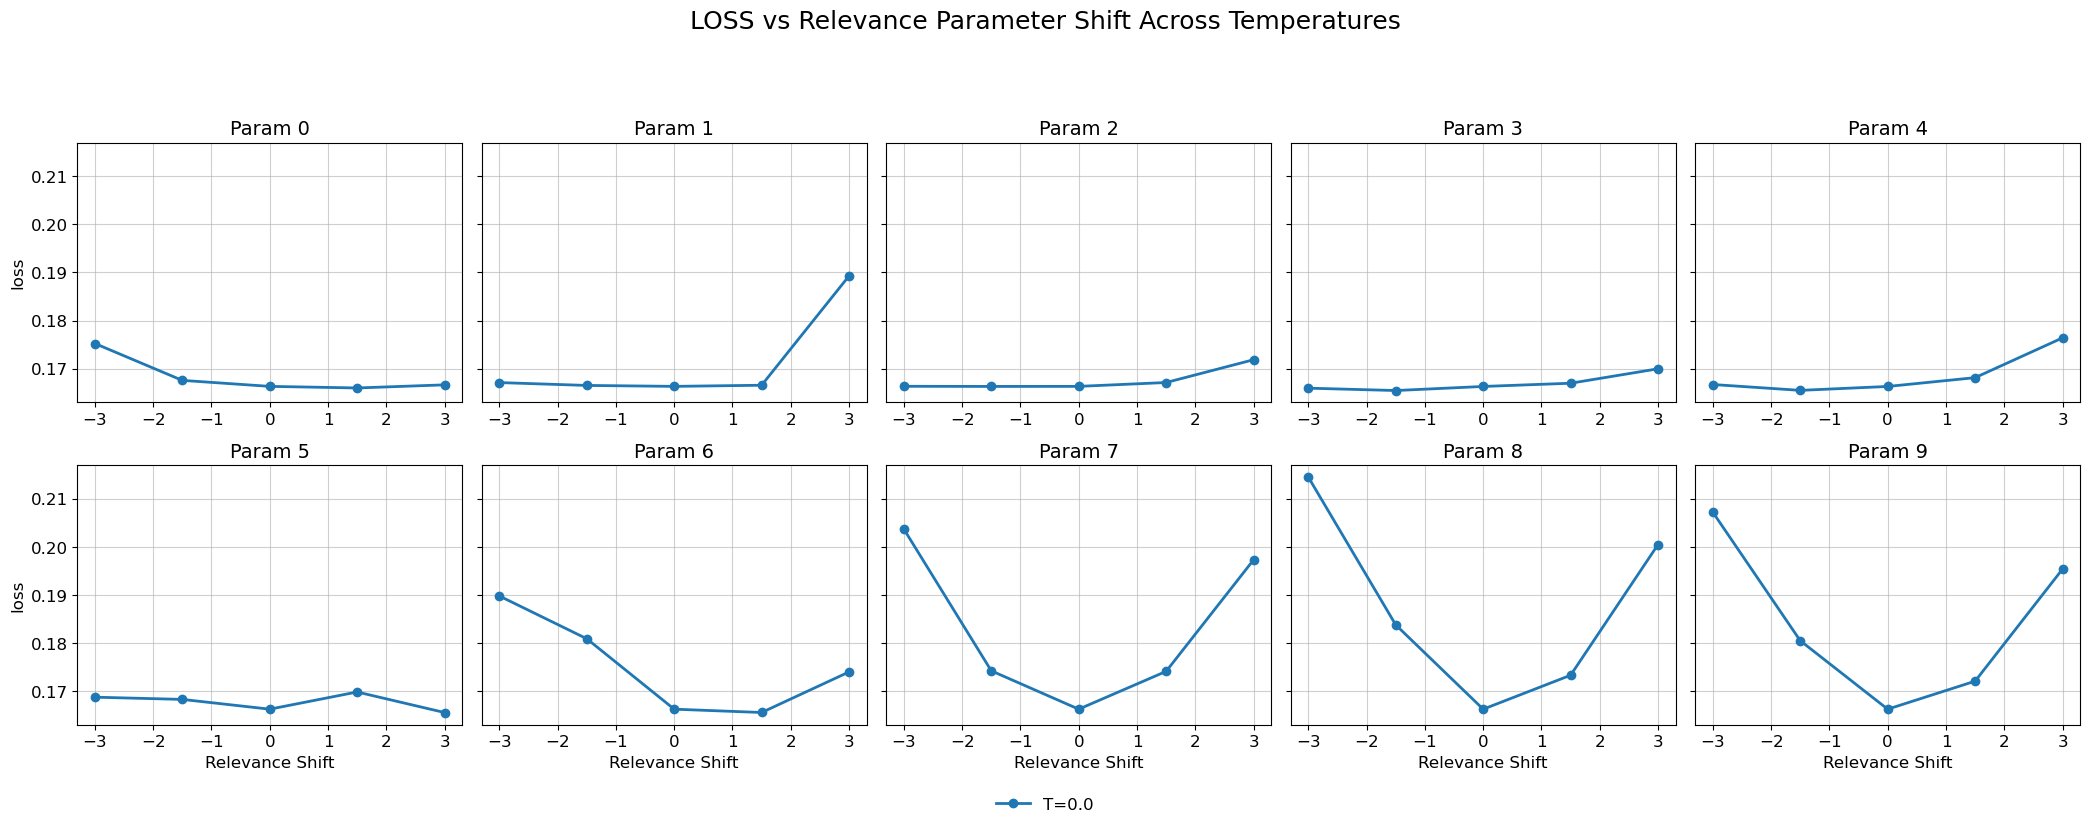

Plotting for bias type: media_type


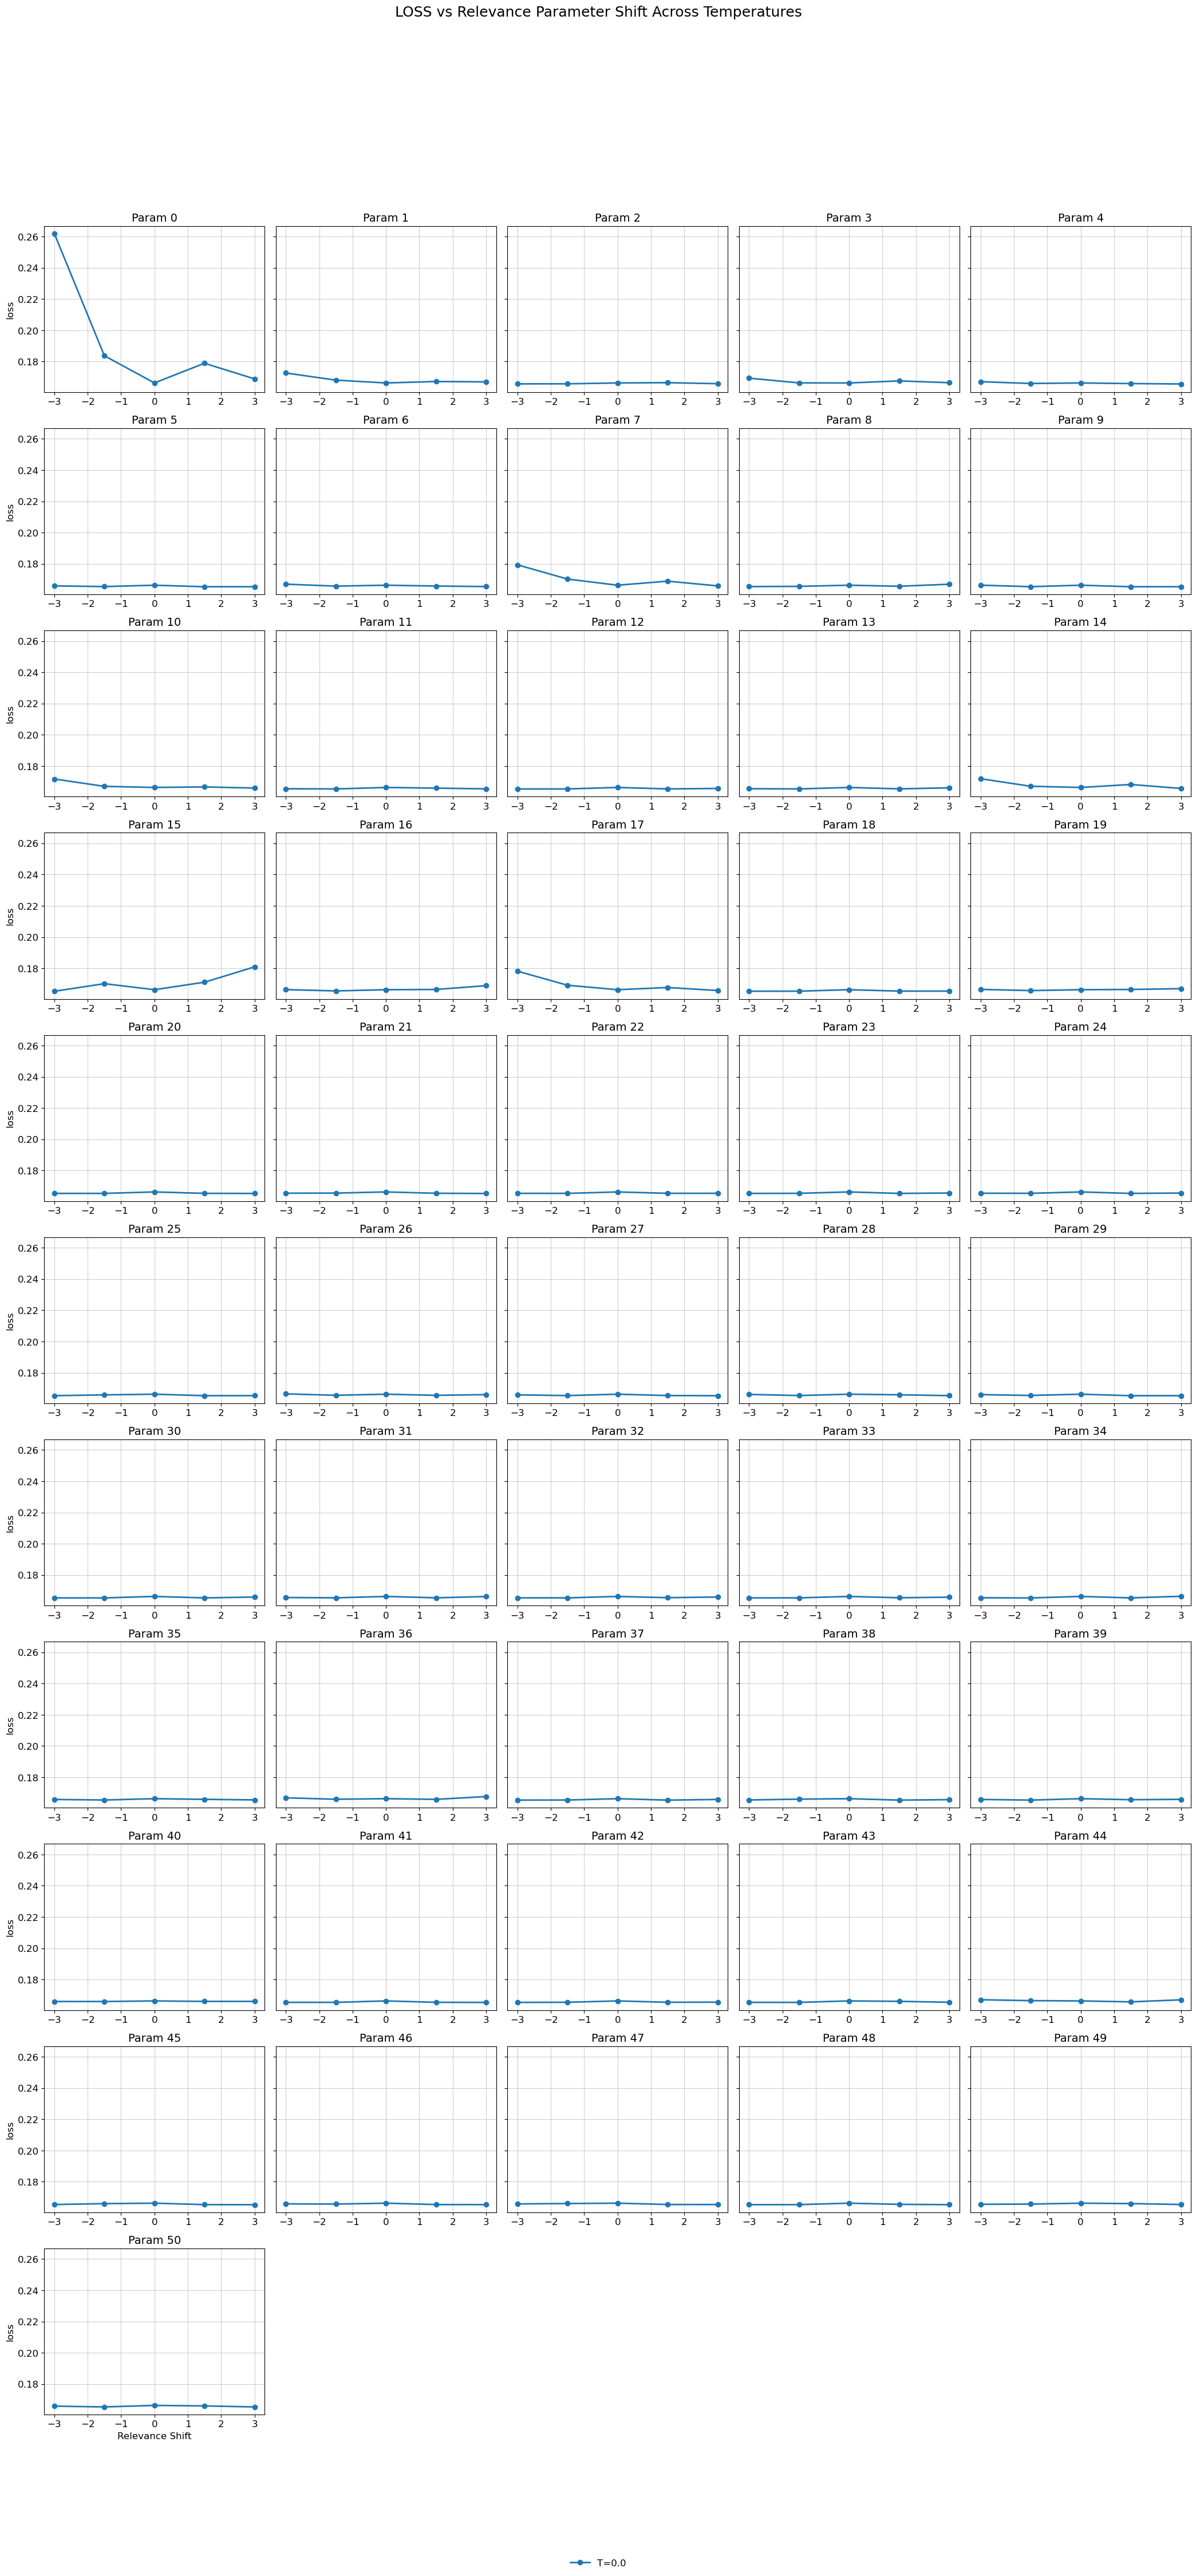

Plotting for bias type: position


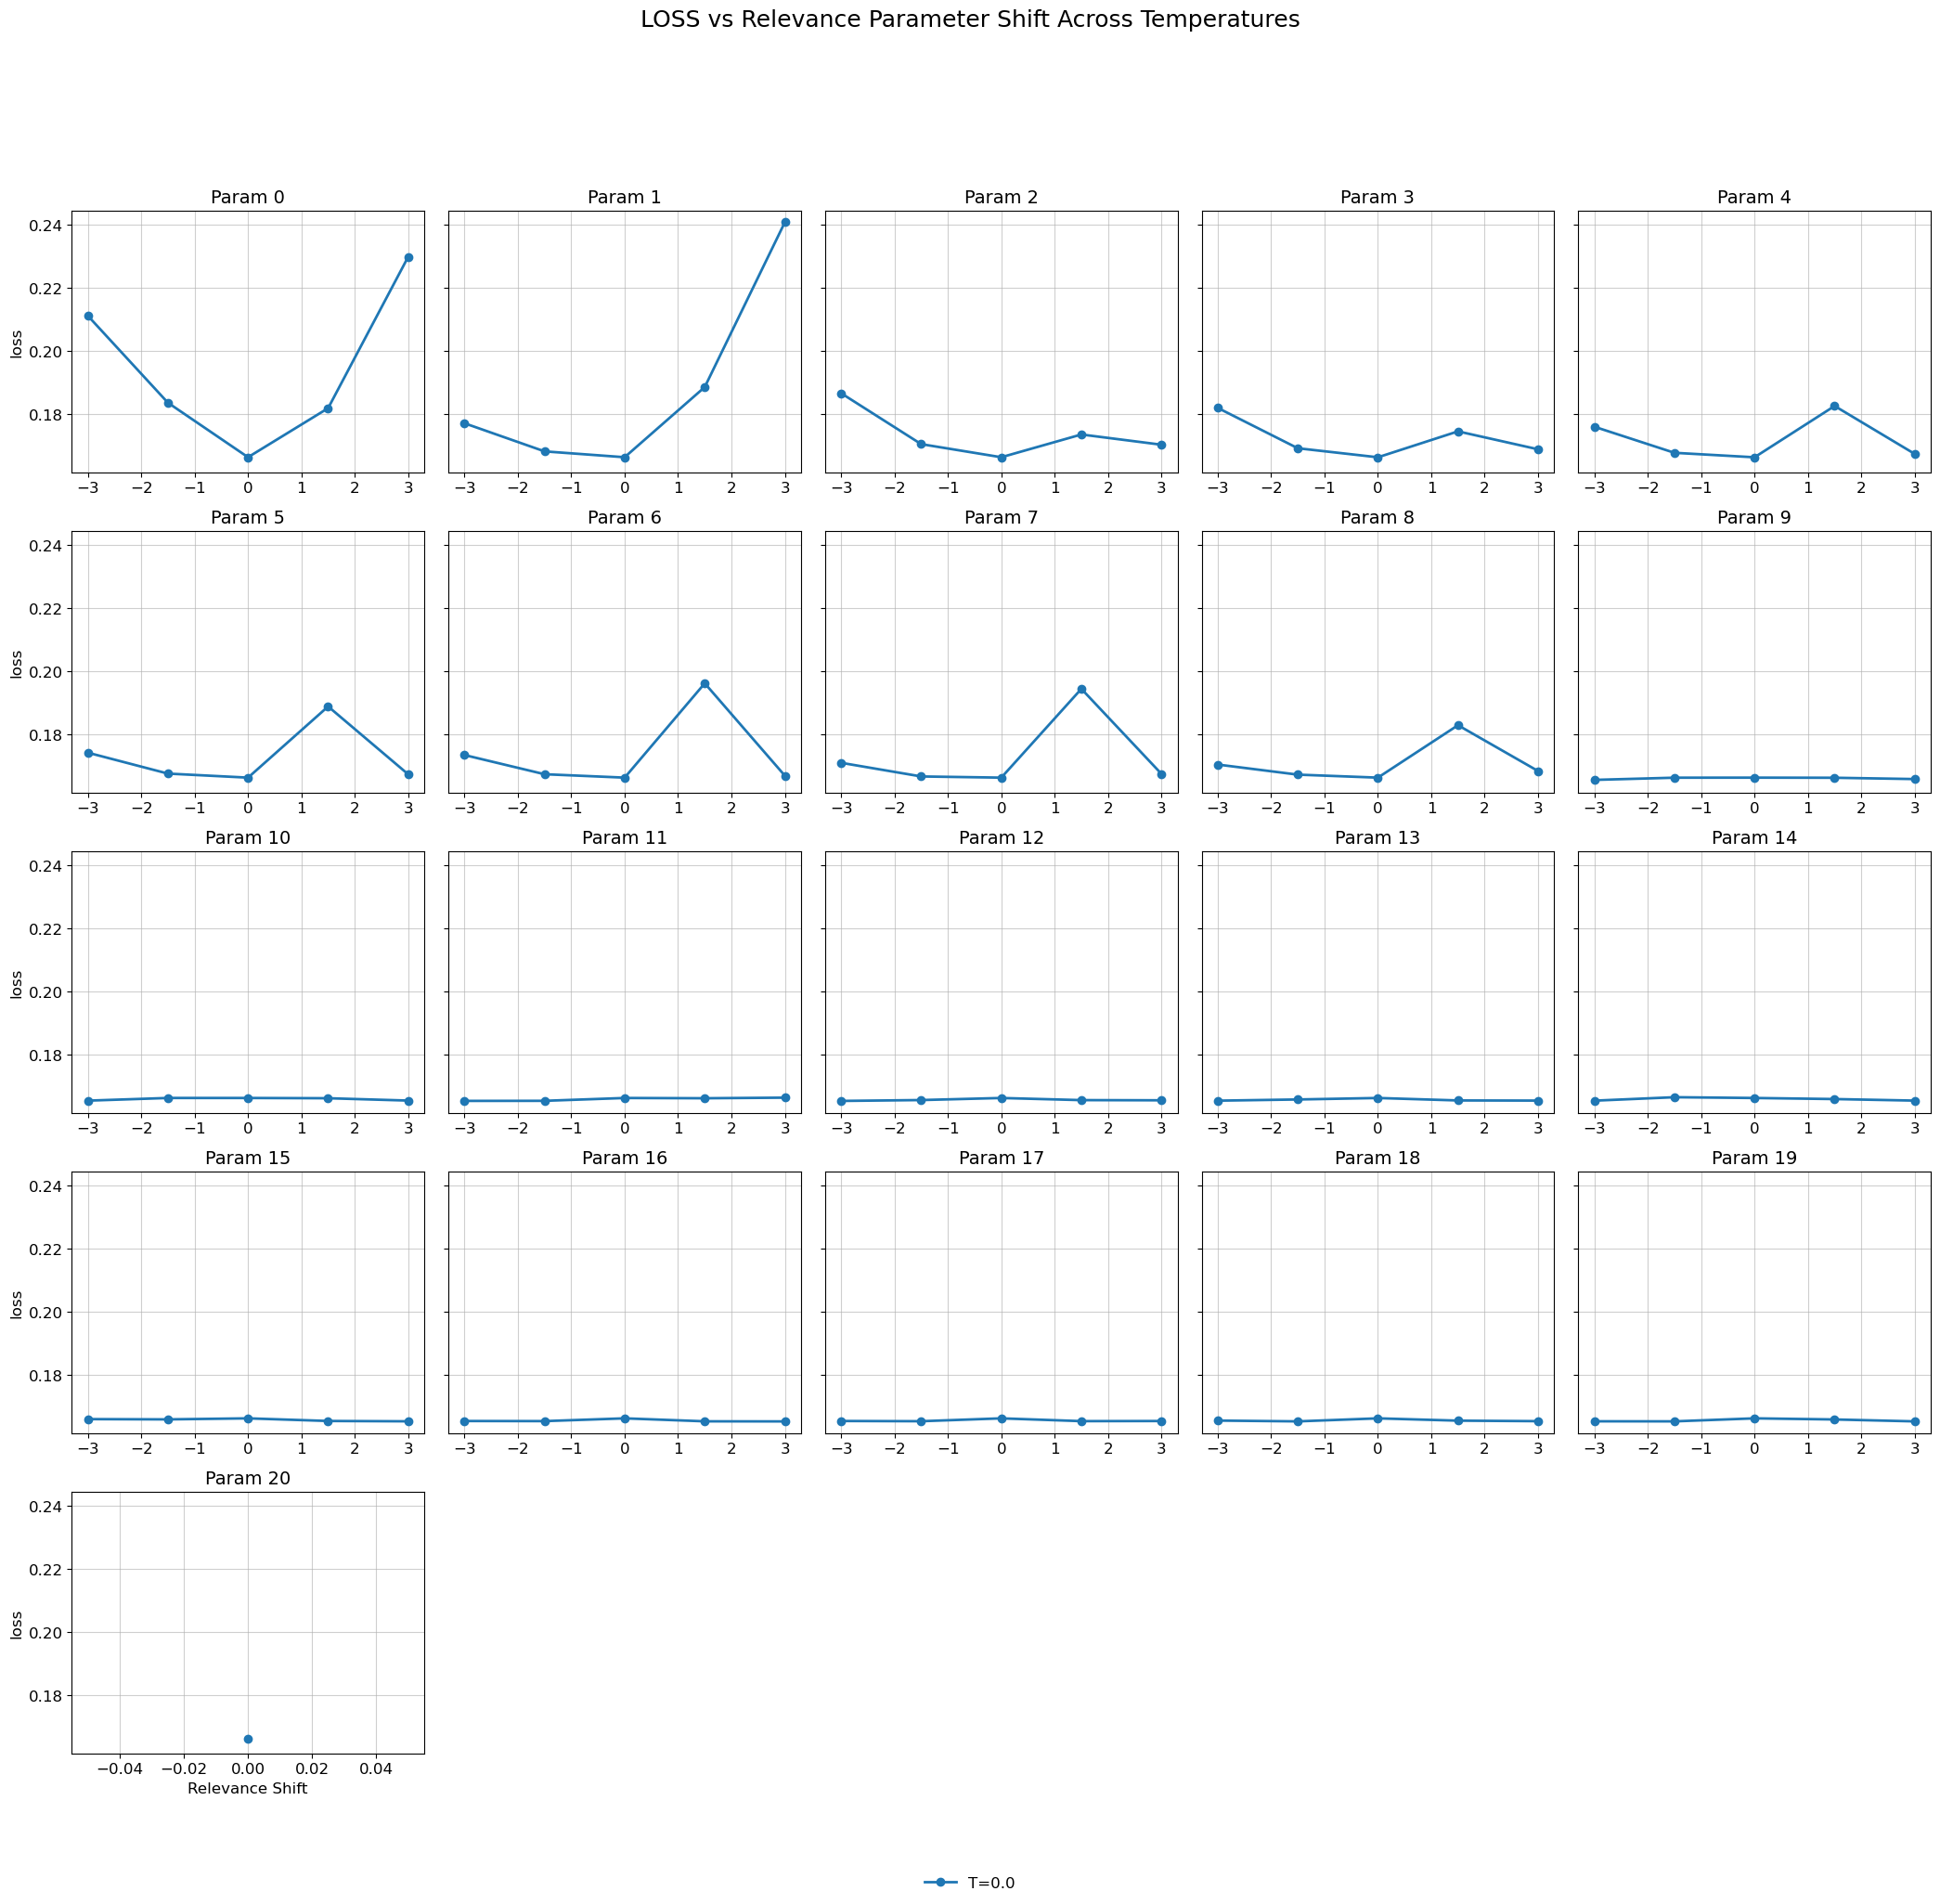

Plotting for bias type: serp_height


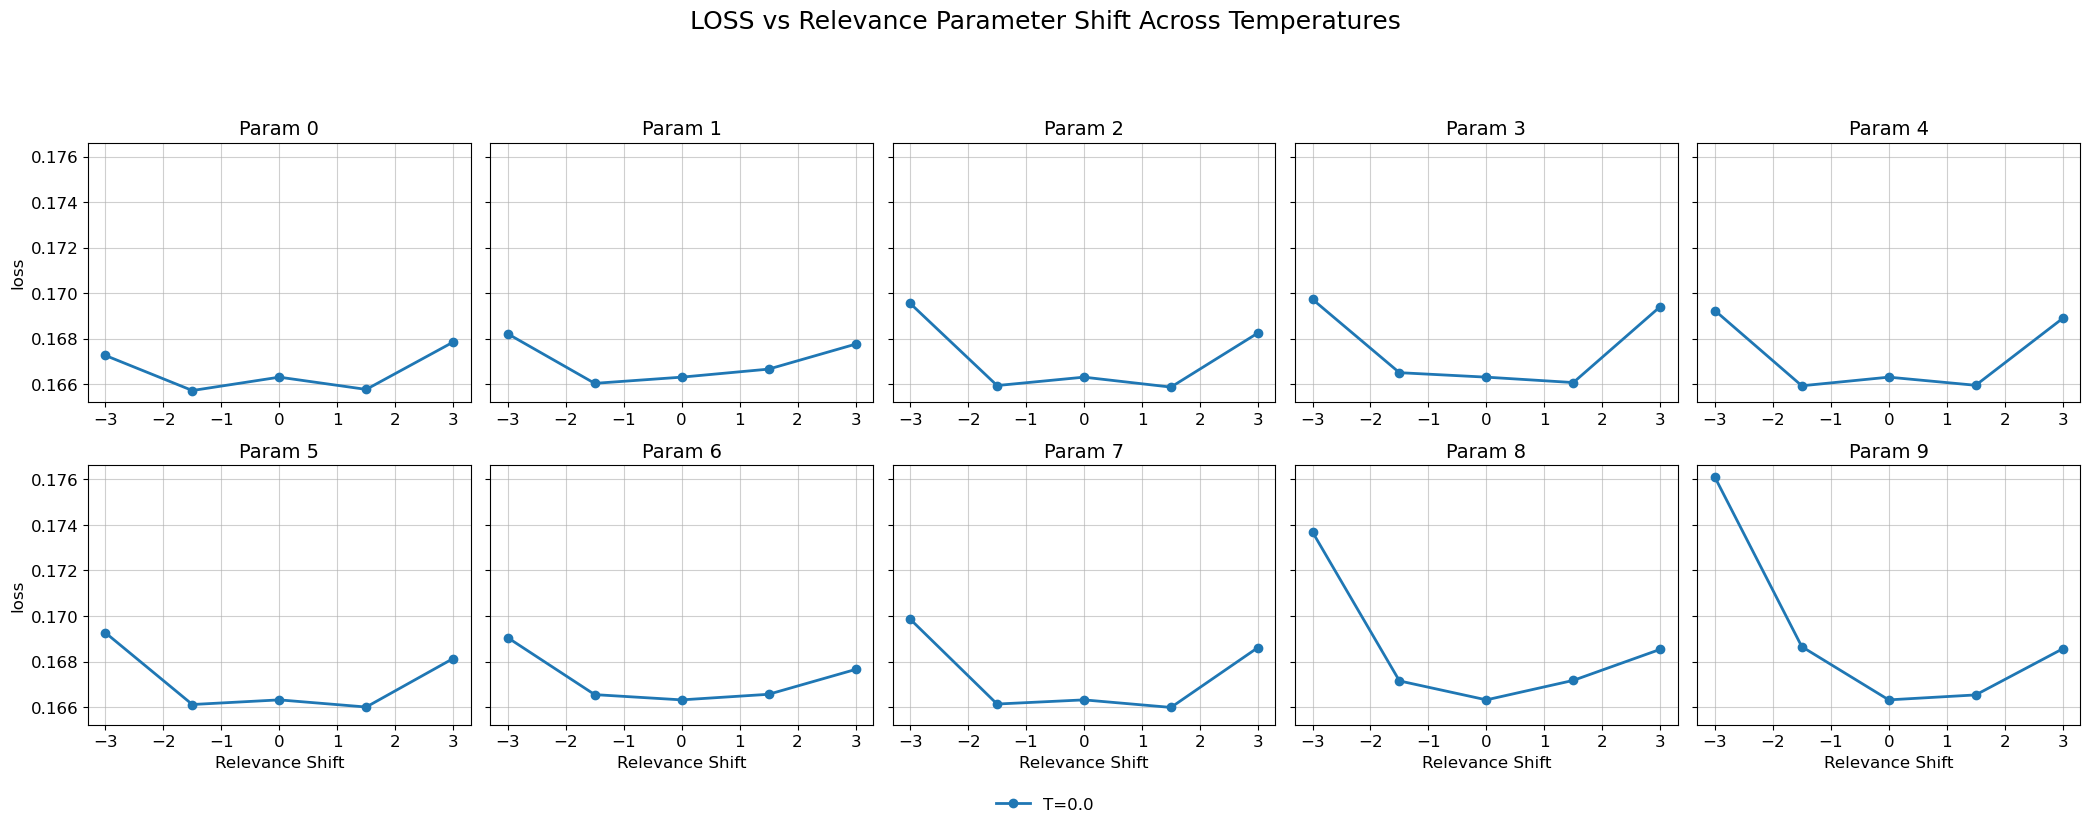

Plotting for bias type: slipoff_count_after_click


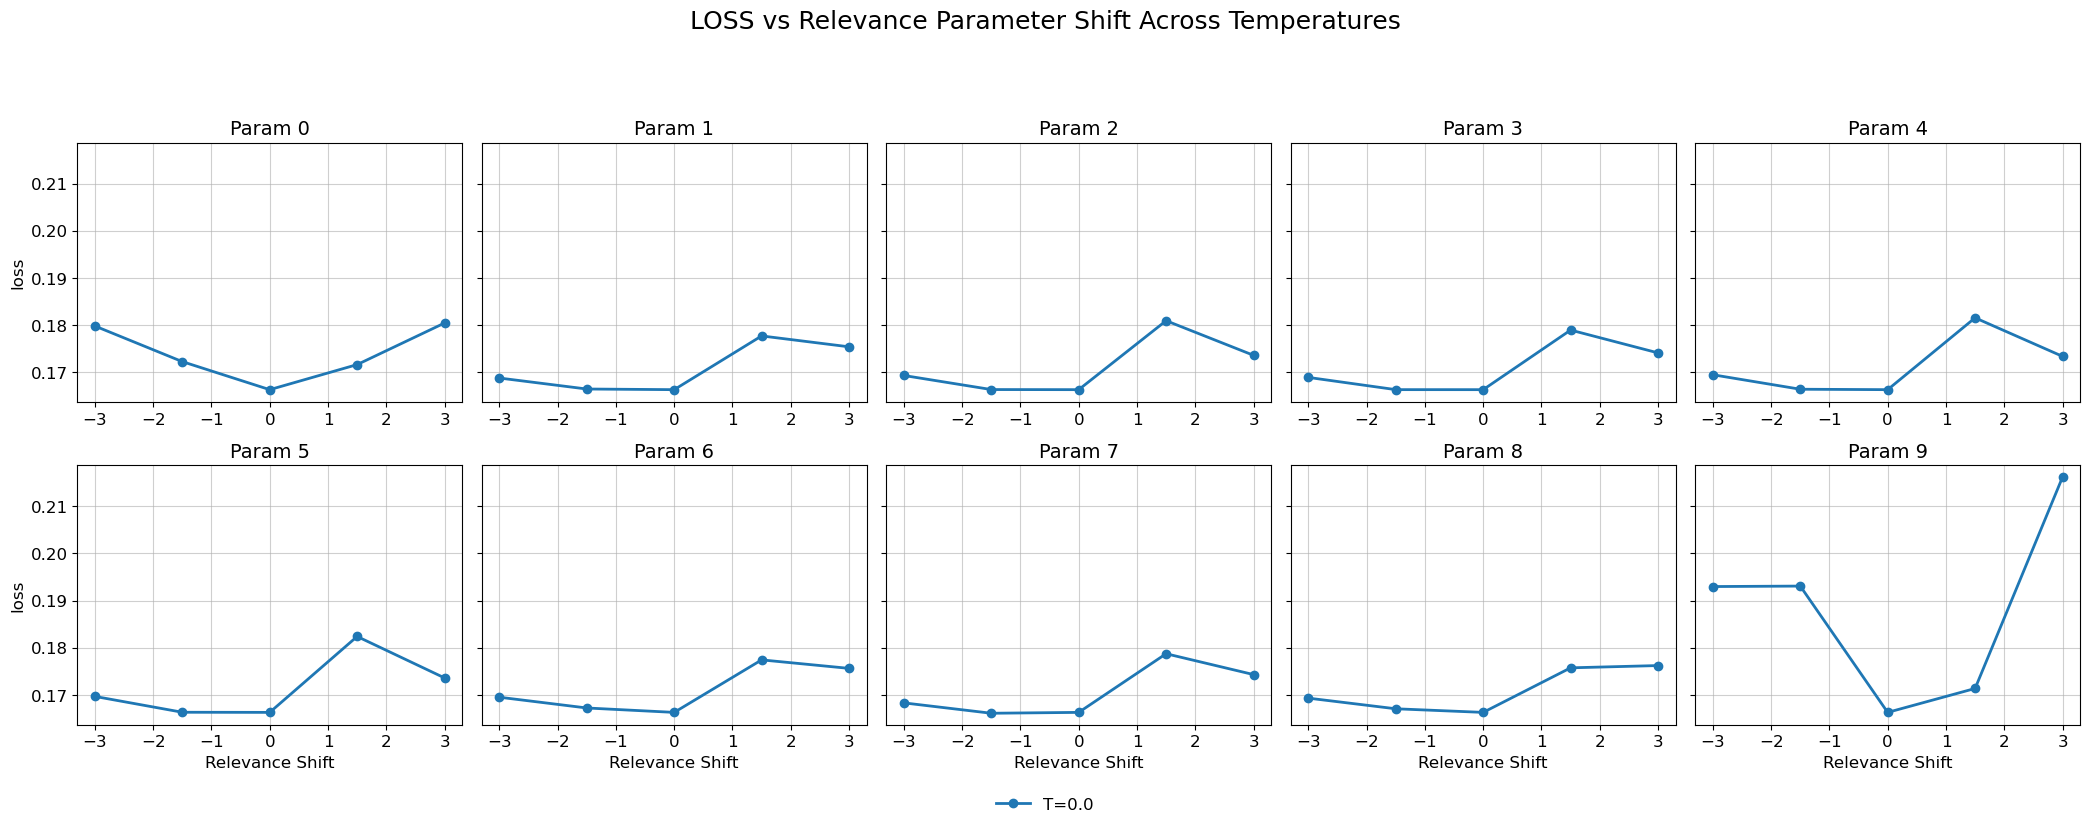

In [13]:

prefix_performance_clicks = 'test_clicks_param_shift_'
prefix_performance_relevance = 'test_relevance_param_shift_'

folder_path = "results/test_baidu/baidu_subset=train_Baidu_ULTRA_part1_multi_bias.npz,bias_tower=multi_embedding,data=Custom_dataset_deep,experiment=test_baidu,logging_policy_ranker=ordered,logging_policy_sampler=e_greedy,policy_temperature=0.0,relevance=deep,relevance_tower=deeper"


# Load performance (clicks)
perf_df = load_and_concat_multi_shift_files(
    folder_path,
    prefix_performance_clicks,
    'relevance_shift',
    'param_idx',
    multi_bias=True
)


# ✅ Now you can plot, just reversing the meaning of the axes
# plot_mean_relevance_shift_combined(all_multi_relevance_dfs, doc_group_sizes, temperatures)
for bias_type in perf_df["bias_type"].unique():
    print(f"Plotting for bias type: {bias_type}")
    subset_df = perf_df[perf_df["bias_type"] == bias_type]
    plot_performance_grid_all_temps([subset_df], [0.0], metric='loss')

In [18]:
perf_df["bias_type"].unique()

array(['displayed_time', 'media_type', 'position', 'serp_height',
       'slipoff_count_after_click'], dtype=object)

In [19]:
data = np.load("../ltr_datasets/train_Baidu_ULTRA_part1_multi_bias.npz", allow_pickle=True)
lp_feature_names = ["position", "media_type", "displayed_time", "serp_height", "slipoff_count_after_click"]

count_map = {}


for idx, lp_feature_name in enumerate(lp_feature_names):
    padded_positions = data['lp_query_doc_features'][:, :, idx].flatten()
    unique, counts = np.unique(padded_positions, return_counts=True)

    # each unique value corresponds to a param_idx used in the experiment
    for u, c in zip(unique, counts):
        if u == 0:
            count_map[(lp_feature_name, int(u))] = int(c) - np.logical_not(data['mask']).sum()
        else:
            count_map[(lp_feature_name, int(u))] = int(c)

# Now apply context-dependent mapping
perf_df["sample_count"] = perf_df.apply(
    lambda row: count_map.get((row["bias_type"], row["param_idx"]), np.nan),
    axis=1
)


Identifiability results for bias type: displayed_time
Param |   Neg p |   Neg Δ |   Pos Δ |  Avg ΔLoss |  Samples |             Conclusion
-----------------------------------------------------------------------------------------------
    0 |  0.0001 |    -1.5 |     3.0 |   0.002038 | 2422655.0 |             identified
    1 |  0.0001 |    -1.5 |     1.5 |   0.004843 | 2422660.0 |             identified
    2 |   0.001 |    -3.0 |     1.5 |   0.001279 | 2422660.0 |             identified
    3 |    None |    None |     1.5 |   0.000622 | 2422655.0 | practically unidentified
    4 |  0.0001 |    -3.0 |     1.5 |   0.002296 | 2422660.0 |             identified
    5 |  0.0001 |    -1.5 |     1.5 |   0.001474 | 2422660.0 |             identified
    6 |  0.0001 |    -1.5 |     3.0 |   0.009031 | 2422655.0 |             identified
    7 |  0.0001 |    -1.5 |     1.5 |   0.016839 | 2422660.0 |             identified
    8 |  0.0001 |    -1.5 |     1.5 |   0.021378 | 2422660.0 |            

/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_75060/2605369127.py:273: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


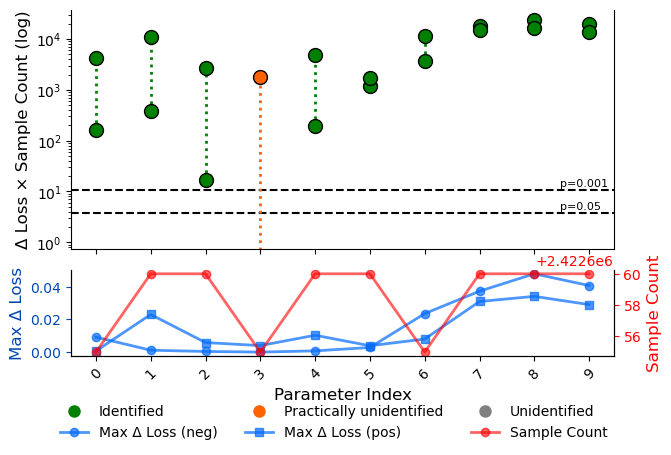


Identifiability results for bias type: media_type
Param |   Neg p |   Neg Δ |   Pos Δ |  Avg ΔLoss |  Samples |             Conclusion
-----------------------------------------------------------------------------------------------
    0 |  0.0001 |    -1.5 |     1.5 |   0.025649 | 16656010.0 |             identified
    1 |  0.0001 |    -1.5 |     1.5 |   0.001966 | 287335.0 |             identified
    2 |    None |    None |    None |  -0.000273 |  15180.0 |           unidentified
    3 |  0.0001 |    -3.0 |     1.5 |   0.000923 | 185760.0 |             identified
    4 |    0.05 |    -3.0 |    None |  -0.000108 |  58665.0 | practically unidentified
    5 |    None |    None |    None |  -0.000646 |   9080.0 |           unidentified
    6 |   0.001 |    -3.0 |    None |  -0.000260 | 110115.0 | practically unidentified
    7 |  0.0001 |    -1.5 |     1.5 |   0.003824 | 704600.0 |             identified
    8 |    None |    None |     3.0 |  -0.000329 |  43560.0 | practically unidenti

/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_75060/2605369127.py:273: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


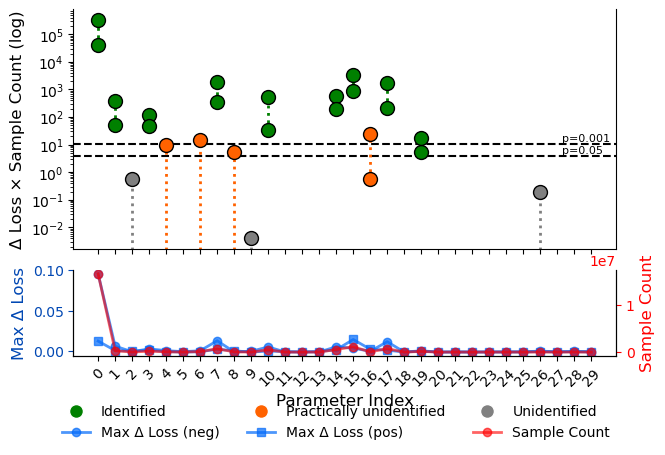


Identifiability results for bias type: position
Param |   Neg p |   Neg Δ |   Pos Δ |  Avg ΔLoss |  Samples |             Conclusion
-----------------------------------------------------------------------------------------------
    0 |  0.0001 |    -1.5 |     1.5 |   0.028237 | 2500800.0 |             identified
    1 |  0.0001 |    -1.5 |     1.5 |   0.021867 | 2427380.0 |             identified
    2 |  0.0001 |    -1.5 |     1.5 |   0.007135 | 2578605.0 |             identified
    3 |  0.0001 |    -1.5 |     1.5 |   0.005847 | 2572430.0 |             identified
    4 |  0.0001 |    -1.5 |     1.5 |   0.005683 | 2593235.0 |             identified
    5 |  0.0001 |    -1.5 |     1.5 |   0.006556 | 2624270.0 |             identified
    6 |  0.0001 |    -1.5 |     1.5 |   0.007750 | 2747285.0 |             identified
    7 |  0.0001 |    -1.5 |     1.5 |   0.006878 | 2606520.0 |             identified
    8 |  0.0001 |    -1.5 |     1.5 |   0.004758 | 2782985.0 |             identif

/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_75060/1413385744.py:46: RuntimeWarning: invalid value encountered in scalar divide
  sub["delta_loss_times_samples"].sum() /
/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_75060/2605369127.py:273: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


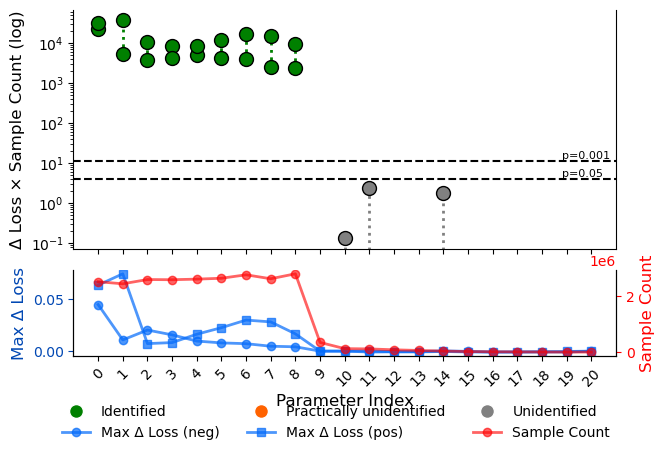


Identifiability results for bias type: serp_height
Param |   Neg p |   Neg Δ |   Pos Δ |  Avg ΔLoss |  Samples |             Conclusion
-----------------------------------------------------------------------------------------------
    0 |  0.0001 |    -3.0 |     3.0 |   0.000273 | 2422655.0 |             identified
    1 |  0.0001 |    -3.0 |     1.5 |   0.000687 | 2422660.0 |             identified
    2 |  0.0001 |    -3.0 |     3.0 |   0.000875 | 2422660.0 |             identified
    3 |  0.0001 |    -1.5 |     3.0 |   0.001296 | 2422655.0 |             identified
    4 |  0.0001 |    -3.0 |     3.0 |   0.000954 | 2422660.0 |             identified
    5 |  0.0001 |    -3.0 |     3.0 |   0.000849 | 2422660.0 |             identified
    6 |  0.0001 |    -1.5 |     1.5 |   0.000909 | 2422655.0 |             identified
    7 |  0.0001 |    -3.0 |     3.0 |   0.001066 | 2422660.0 |             identified
    8 |  0.0001 |    -1.5 |     1.5 |   0.002257 | 2422660.0 |             iden

/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_75060/2605369127.py:273: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


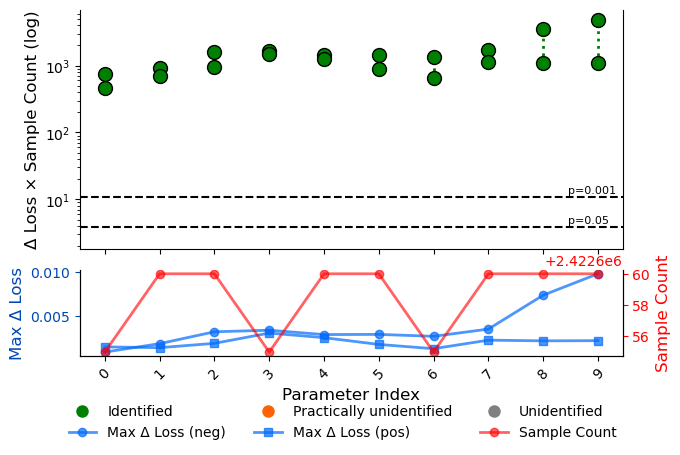


Identifiability results for bias type: slipoff_count_after_click
Param |   Neg p |   Neg Δ |   Pos Δ |  Avg ΔLoss |  Samples |             Conclusion
-----------------------------------------------------------------------------------------------
    0 |  0.0001 |    -1.5 |     1.5 |   0.007773 | 2422655.0 |             identified
    1 |  0.0001 |    -1.5 |     1.5 |   0.004614 | 2422660.0 |             identified
    2 |   0.001 |    -1.5 |     1.5 |   0.004985 | 2422660.0 |             identified
    3 |  0.0001 |    -3.0 |     1.5 |   0.004605 | 2422655.0 |             identified
    4 |  0.0001 |    -1.5 |     1.5 |   0.005107 | 2422660.0 |             identified
    5 |   0.001 |    -1.5 |     1.5 |   0.005361 | 2422660.0 |             identified
    6 |  0.0001 |    -1.5 |     1.5 |   0.004921 | 2422655.0 |             identified
    7 |  0.0001 |    -3.0 |     1.5 |   0.004455 | 2422660.0 |             identified
    8 |  0.0001 |    -1.5 |     1.5 |   0.004630 | 2422660.0 |   

/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_75060/2605369127.py:273: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


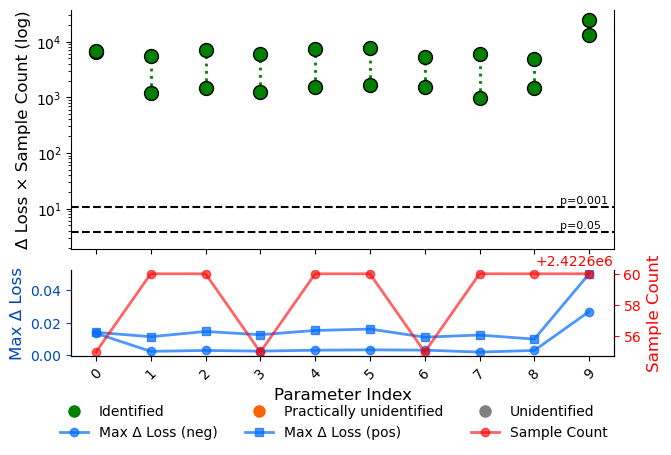

In [20]:
from scipy.stats import chi2

# Usage
perf_df=perf_df[perf_df["param_idx"] < 30]
for bias_type in perf_df.bias_type.unique():
    subset_df = perf_df.loc[perf_df["bias_type"] == bias_type].copy()  # <--- FIX

    baseline_loss = perf_df.loc[perf_df["relevance_shift"] == 0, "loss"].mean()
    perf_df["delta_loss"] = perf_df["loss"] - baseline_loss
    perf_df["delta_loss_times_samples"] = perf_df["delta_loss"] * perf_df["sample_count"]

    # Compute global delta loss first
    baseline_loss = subset_df.loc[subset_df["relevance_shift"] == 0, "loss"].mean()

    subset_df["delta_loss"] = subset_df["loss"] - baseline_loss
    subset_df["delta_loss_times_samples"] = subset_df["delta_loss"] * subset_df["sample_count"]
    print(f"\nIdentifiability results for bias type: {bias_type}")
    identifiability_results = compute_identifiability(
        subset_df,
        thresholds=[0.05, 0.001, 0.0001]
    )

    _, _, = plot_identifiability_summary(
    identifiability_results,
    perf_df[perf_df["bias_type"] == bias_type],
    output_path=f"notebooks/plots/{bias_type}_bias_Identifiability_BaiduULTRA_multi_bias.pdf",
    x_tick_rotation=45
    )

